# Step 11: Build the Land Use Model in UrbanSim Python
### LUTI Model — Kandy District, Sri Lanka
**Project:** 20GES1432 — Integrated Land Use–Transport Interaction Model  
**Author:** K. Abishek | Sabaragamuwa University of Sri Lanka  
**Supervisor:** Prof. RMKGSPB Koswatte | **Phase:** 2 — Baseline Model Setup

---

## Overview

This notebook implements **Step 11** of the LUTI methodology: building the baseline land use model using the open-source **UrbanSim Python** libraries (replacing the commercial UrbanSim Platform).

UrbanSim captures the **second-order feedback effects** a standalone transport model cannot:

> *New road built → accessibility improves → land becomes attractive → households/firms relocate → prices rise → new construction → more traffic generated.*

### Sub-steps in this notebook

| Sub-step | Component | What it does |
|---|---|---|
| 11.1 | **Zones table** | One row per TAZ: population, employment, area |
| 11.2 | **Buildings table** | Synthesises building records from Census housing data |
| 11.3 | **Households table** | Synthesises households with HIES 2019 income proxies |
| 11.4 | **Jobs table** | Individual job records by sector |
| 11.5 | **Hedonic Price Model** | OLS regression: land value from location attributes |
| 11.6 | **HLCM** | MNL model: where households choose to live |
| 11.7 | **Developer Model** | New construction under zoning constraints |

### Data inputs

| File | Role |
|---|---|
| `Census to Taz System/Kandy_TAZ_With_SocioEconomic.shp` | TAZ boundaries, population, households |
| `Kandy_GN_Employment_2024.xlsx` | GN-level employment by sector |
| `HH_Income_GN_SriLanka.xlsx` | Household income — HIES 2019 proxy |
| `Census Data/OHU_GN_excel (1).xlsx` | Occupied Housing Units per GN |
| `Kandy_Property_Values_Dataset.xlsx` | Property prices for hedonic regression |
| `Kandy_LandUse_Zoning_Dataset.xlsx` | UDA zoning constraints |


---
## Cell 1 — Install Required Packages

Run once. Safe to re-run if packages are already installed (~1–2 min).

> **NumPy note:** UrbanSim and Orca reference `numpy.core.umath_tests` which was  
> removed in NumPy 1.24. **Cell 2 applies a two-line compatibility shim** that fixes  
> this at import time — no NumPy downgrade needed.


In [1]:
# ── CELL 1: Install Required Packages ───────────────────────────────────────
import subprocess, sys

packages = [
    "geopandas",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scipy",
    "statsmodels",
    "scikit-learn",
    "openpyxl",
    "pyproj",
    "shapely",
    "orca>=1.5",      # 1.5+ has partial numpy.core fix; Cell 2 shim covers the rest
    "urbansim>=3.2",  # 3.2+ compatible with NumPy 1.24+
]

print("Installing packages...")
for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    status = "\u2713" if result.returncode == 0 else "\u2717 (check manually)"
    print(f"  {status} {pkg}")

print("\nDone. Proceed to Cell 2.")


Installing packages...
  ✓ geopandas
  ✓ pandas
  ✓ numpy
  ✓ matplotlib
  ✓ seaborn
  ✓ scipy
  ✓ statsmodels
  ✓ scikit-learn
  ✓ openpyxl
  ✓ pyproj
  ✓ shapely
  ✓ orca>=1.5
  ✓ urbansim>=3.2

Done. Proceed to Cell 2.


---
## Cell 2 — Imports

The **NumPy compatibility shim** (lines 10–14 below) solves the  
`No module named 'numpy.core.umath_tests'` error on NumPy ≥ 1.24.  
It registers an empty stub module before UrbanSim/Orca are imported,  
satisfying the internal reference without requiring a NumPy downgrade.


In [2]:
# ── CELL 2: Imports ──────────────────────────────────────────────────────────
import os
import sys
import types
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.preprocessing import LabelEncoder

# ── NumPy ≥ 1.24 / 2.0 compatibility shim for UrbanSim / Orca ───────────────
# Two things were removed from NumPy that UrbanSim / Orca still reference:
#
#   1. numpy.core.umath_tests  (removed in NumPy 1.24)
#      → Register an empty stub module so the import doesn't raise ModuleNotFoundError.
#
#   2. numpy.core.umath_tests.inner1d  (removed in NumPy 2.0)
#      → inner1d(a, b) computes the row-wise inner product of two arrays.
#        It is equivalent to np.einsum('...i,...i->...', a, b).
#        We attach a pure-NumPy replacement to the stub so any code that
#        calls it gets a correct result.
#
# Both fixes are safe on all NumPy versions and do not affect model outputs.
if "numpy.core.umath_tests" not in sys.modules:
    _compat_stub = types.ModuleType("numpy.core.umath_tests")
    sys.modules["numpy.core.umath_tests"] = _compat_stub
else:
    _compat_stub = sys.modules["numpy.core.umath_tests"]

# Attach inner1d if it is missing from the stub (NumPy 2.0+)
if not hasattr(_compat_stub, "inner1d"):
    def _inner1d(a, b):
        """Row-wise inner product — replacement for numpy.core.umath_tests.inner1d."""
        a, b = np.asarray(a), np.asarray(b)
        return np.einsum("...i,...i->...", a, b)
    _compat_stub.inner1d = _inner1d
# ─────────────────────────────────────────────────────────────────────────────

# ── UrbanSim / Orca imports ───────────────────────────────────────────────────
# Orca (table registration framework) is the only hard requirement.
# The urbansim model classes (MNLLocationChoiceModel, RegressionModel) are
# optional — the notebook uses manual implementations of every model, so
# missing these classes does not affect any output.
#
# Import strategy:
#   Step 1 — import orca alone (sets URBANSIM_AVAILABLE)
#   Step 2 — try the urbansim model classes from their correct sub-modules;
#             log a note if unavailable but do NOT set URBANSIM_AVAILABLE = False.

URBANSIM_AVAILABLE = False
try:
    import orca
    URBANSIM_AVAILABLE = True
    print(f"\u2713 Orca imported  (version: {orca.__version__})")
except ImportError as e:
    print(f"\u26a0 Orca not available: {e}")
    print("  Tables will be stored as plain DataFrames (no Orca registration).")

# Try urbansim model classes — several possible locations depending on version
RegressionModel         = None
MNLLocationChoiceModel  = None
for _mod, _cls in [
    ("urbansim.models",         "RegressionModel"),
    ("urbansim.models.regression", "RegressionModel"),
    ("urbansim.models",         "MNLLocationChoiceModel"),
    ("urbansim.models.lcm",     "MNLLocationChoiceModel"),
]:
    try:
        import importlib
        _m = importlib.import_module(_mod)
        _c = getattr(_m, _cls, None)
        if _c is not None:
            if _cls == "RegressionModel":
                RegressionModel = _c
            else:
                MNLLocationChoiceModel = _c
    except Exception:
        pass

_found = [c for c, v in [("RegressionModel", RegressionModel),
                          ("MNLLocationChoiceModel", MNLLocationChoiceModel)]
          if v is not None]
_missing = [c for c, v in [("RegressionModel", RegressionModel),
                            ("MNLLocationChoiceModel", MNLLocationChoiceModel)]
            if v is None]
if _found:
    print(f"\u2713 urbansim model classes found   : {_found}")
if _missing:
    print(f"\u2139 urbansim model classes missing : {_missing}")
    print("  (Not needed — notebook uses statsmodels OLS + manual HLCM throughout)")

# Plotting style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print(f"\n\u2713 Core imports OK")
print(f"  NumPy     : {np.__version__}")
print(f"  Pandas    : {pd.__version__}")
print(f"  GeoPandas : {gpd.__version__}")


✓ Orca imported  (version: 1.8)
✓ urbansim model classes found   : ['RegressionModel']
ℹ urbansim model classes missing : ['MNLLocationChoiceModel']
  (Not needed — notebook uses statsmodels OLS + manual HLCM throughout)

✓ Core imports OK
  NumPy     : 2.4.4
  Pandas    : 3.0.2
  GeoPandas : 1.1.3


---
## Cell 3 — Data Paths

> **Check `DATA_DIR`** before running.  
> If this notebook is in `E:\\LUTI Research\\kandy_luti\\`, the relative path  
> `../20GES1432_RESEARCH/Data` is correct. Otherwise set the full absolute path.


In [3]:
# ── CELL 3: Configure Data Paths ────────────────────────────────────────────
# ─── Set this to your data folder ───────────────────────────────────────────


from pathlib import Path

DATA_DIR = Path(r"E:/LUTI Research/20GES1432_RESEARCH/Data")
OUTPUT_DIR = Path(r"E:/LUTI Research/kandy_luti/matsim")

PATHS = {
    "taz_shp": DATA_DIR / "Census to Taz System" / "Kandy_TAZ_With_SocioEconomic.shp",
    "employment": DATA_DIR / "Kandy_GN_Employment_2024.xlsx",
    "income": DATA_DIR / "HH_Income_GN_SriLanka.xlsx",
    "ohu": DATA_DIR / "Census Data" / "OHU_GN_excel (1).xlsx",
    "property": DATA_DIR / "Kandy_Property_Values_Dataset.xlsx",
    "zoning": DATA_DIR / "Kandy_LandUse_Zoning_Dataset.xlsx",
}

print("Verifying data files...")
all_ok = True
for name, path in PATHS.items():
    exists = os.path.exists(path)
    status = "\u2713" if exists else "\u2717 MISSING"
    print(f"  {status}  [{name:12s}]  {os.path.basename(path)}")
    if not exists:
        all_ok = False

if all_ok:
    print(f"\n\u2713 All {len(PATHS)} files found.")
else:
    print("\n\u26a0 Some files missing — check DATA_DIR path.")
print(f"Output dir: {OUTPUT_DIR}")


Verifying data files...
  ✓  [taz_shp     ]  Kandy_TAZ_With_SocioEconomic.shp
  ✓  [employment  ]  Kandy_GN_Employment_2024.xlsx
  ✓  [income      ]  HH_Income_GN_SriLanka.xlsx
  ✓  [ohu         ]  OHU_GN_excel (1).xlsx
  ✓  [property    ]  Kandy_Property_Values_Dataset.xlsx
  ✓  [zoning      ]  Kandy_LandUse_Zoning_Dataset.xlsx

✓ All 6 files found.
Output dir: E:\LUTI Research\kandy_luti\matsim


---
## Cell 4 — Helper Functions

In [4]:
# ── CELL 4: Helper Functions ────────────────────────────────────────────────

def clean_col(df):
    df.columns = (df.columns.astype(str)
                             .str.replace("\n","_",regex=False)
                             .str.strip()
                             .str.replace(r"\s+","_",regex=True)
                             .str.replace(r"[^\w]","",regex=True))
    return df

def safe_num(s):
    return pd.to_numeric(s, errors="coerce").fillna(0)

def table_summary(name, df):
    print(f"\n{'='*58}\n  TABLE: {name}\n{'='*58}")
    print(f"  Rows: {len(df):,}   Cols: {list(df.columns[:6])}...")
    for c in df.select_dtypes("number").columns[:6]:
        print(f"  {c:28s} min={df[c].min():>12,.1f}  max={df[c].max():>12,.1f}")
    print("="*58)

def save_csv(df, name):
    p = os.path.join(OUTPUT_DIR, f"{name}.csv")
    df.to_csv(p)
    print(f"  Saved \u2192 {p}")

print("\u2713 Helpers defined.")


✓ Helpers defined.


---
## Sub-step 11.1 — Zones Table

Each row = one TAZ (GN Division). This is the spatial backbone — all other  
tables link back here via `zone_id`.

**Key columns:** `zone_id`, `population`, `num_households`, `total_employment`,  
`emp_industry`, `emp_services`, `emp_agriculture`, `zone_type`, `accessibility`  
(accessibility = 0.0 placeholder; filled from AequilibraE output in Step 12).


In [5]:
# ── CELL 5: Load TAZ Shapefile ───────────────────────────────────────────────
taz_gdf = gpd.read_file(PATHS["taz_shp"])
taz_gdf = clean_col(taz_gdf)
print(f"TAZ loaded: {len(taz_gdf):,} zones   CRS: {taz_gdf.crs}")
print(f"Columns: {list(taz_gdf.columns)}")
print(taz_gdf[["TAZ_ID","GN_Name","DS_Div","Area_sqkm","Pop_Total","Num_Househ"]].head(5).to_string(index=False))


TAZ loaded: 1,194 zones   CRS: EPSG:4326
Columns: ['GN_Name', 'GN_Number', 'PROVINCE_N', 'DISTRICT_N', 'DS_Div', 'GND_NAME_C', 'GND_NAME_G', 'Area_sqkm', 'Population', 'TAZ_ID', 'GN_clean', 'Pop_Total', 'Male', 'Female', 'Num_Househ', 'Households', 'geometry']
 TAZ_ID            GN_Name         DS_Div  Area_sqkm  Pop_Total  Num_Househ
      1     Rajasinghagama   HARISPATTUWA   0.838396     1082.0       287.0
      2      Ranawana West   HARISPATTUWA   0.715116     1642.0       455.0
      3 Welivita Ihalagama HATHARALIYADDA   1.096584      529.0       138.0
      4         Ambalagala    MEDADUMBARA   0.691567      402.0       118.0
      5       Endaruthenna   HARISPATTUWA   0.381392      616.0       161.0


In [6]:
# ── CELL 6: Load and Clean Employment Data ───────────────────────────────────
# Excel structure:
#   row 0-2 : metadata / blank  (skipped by header=3)
#   row 3   : actual column headers  ← pandas uses this as column names
#   row 4+  : data
# With header=3 the columns are ALREADY set correctly — no reassignment needed.
emp_raw = pd.read_excel(PATHS["employment"], sheet_name="GN_Employment_Data", header=3)
emp_raw = clean_col(emp_raw)
emp_raw = emp_raw.dropna(how="all")

# Quick sanity check: print first 3 column names so you can verify
print(f"Employment columns (first 8): {list(emp_raw.columns[:8])}")

print(f"Employment rows: {len(emp_raw):,}   Cols: {list(emp_raw.columns[:8])}...")

# Pick columns by partial name match
def find_col(df, keyword):
    matches = [c for c in df.columns if keyword.lower() in c.lower()]
    return matches[0] if matches else None

C_GN   = find_col(emp_raw, "GN_Number")         or find_col(emp_raw, "Number")
C_ZT   = find_col(emp_raw, "Zone_Type")          or find_col(emp_raw, "Zone")
C_EMP  = find_col(emp_raw, "Total_Employed")
C_IND  = find_col(emp_raw, "Industry_Employed")
C_SVC  = find_col(emp_raw, "Services")

emp = emp_raw[[C_GN, C_ZT, C_EMP, C_IND, C_SVC]].copy()
emp.columns = ["GN_Number","Zone_Type","Total_Employed","Emp_Industry","Emp_Services"]
emp["GN_Number"]      = safe_num(emp["GN_Number"]).astype(int)
emp["Total_Employed"] = safe_num(emp["Total_Employed"]).astype(int)
emp["Emp_Industry"]   = safe_num(emp["Emp_Industry"]).astype(int)
emp["Emp_Services"]   = safe_num(emp["Emp_Services"]).astype(int)
emp["Emp_Agriculture"]= (emp["Total_Employed"] - emp["Emp_Industry"]
                         - emp["Emp_Services"]).clip(lower=0)
print("\nZone type distribution:")
print(emp["Zone_Type"].value_counts().to_string())


Employment columns (first 8): ['Province_Code', 'Province_Name', 'District_Code', 'District_Name', 'DS_Code', 'DS_Division_Name', 'GN_Division_Code', 'GN_Division_Name']
Employment rows: 1,188   Cols: ['Province_Code', 'Province_Name', 'District_Code', 'District_Name', 'DS_Code', 'DS_Division_Name', 'GN_Division_Code', 'GN_Division_Name']...

Zone type distribution:
Zone_Type
Rural         524
Peri-Urban    484
Urban         179


In [7]:
# ── CELL 7: Merge Employment to TAZ ─────────────────────────────────────────
taz_gdf["GN_Number"] = safe_num(taz_gdf["GN_Number"]).astype(int)
taz_m = taz_gdf.merge(emp, on="GN_Number", how="left")
for c in ["Total_Employed","Emp_Industry","Emp_Services","Emp_Agriculture"]:
    taz_m[c] = taz_m[c].fillna(0).astype(int)
taz_m["Zone_Type"] = taz_m["Zone_Type"].fillna("Rural")
print(f"Merged TAZ: {len(taz_m):,}   Zones with emp > 0: {taz_m['Total_Employed'].gt(0).sum():,}")


Merged TAZ: 1,194   Zones with emp > 0: 1,194


In [8]:
# ── CELL 8: Add Average Land Price per Zone ──────────────────────────────────
land_df = pd.read_excel(PATHS["property"], sheet_name="Land_Prices")
kandy_median = land_df["Land_Price_Per_Perch_LKR"].median()

# ── Zone-type based price averages (robust to DS_Division string mismatches) ──
# Property data Zone_Type uses fine-grained categories; taz_m uses Urban/Peri-Urban/Rural.
# Normalise property Zone_Type to the 3 macro categories used in the zones table.
_zt_norm = {
    "Urban_Core":    "Urban",    "Inner_Suburban": "Urban",
    "Outer_Suburban":"Urban",    "Urban":           "Urban",
    "Peri-Urban":   "Peri-Urban","Peri_Urban":     "Peri-Urban",
    "Rural":        "Rural",
}
land_df["_zt_macro"] = (land_df["Zone_Type"].str.strip()
                                            .map(_zt_norm)
                                            .fillna("Urban"))
zt_price = land_df.groupby("_zt_macro")["Land_Price_Per_Perch_LKR"].mean().to_dict()
print("  Zone-type price averages (LKR/perch):")
for k in sorted(zt_price):
    print(f"    {k:12s}: LKR {zt_price[k]:>12,.0f}")

taz_m["Avg_Land_Price"] = (taz_m["Zone_Type"].str.strip()
                                             .map(zt_price)
                                             .fillna(kandy_median))
print(f"Land price range: LKR {taz_m['Avg_Land_Price'].min():,.0f} – {taz_m['Avg_Land_Price'].max():,.0f}/perch")
print(f"  Zones with non-median price: {(taz_m['Avg_Land_Price'] != kandy_median).sum()}")


  Zone-type price averages (LKR/perch):
    Peri-Urban  : LKR      220,000
    Rural       : LKR       91,364
    Urban       : LKR    1,317,794
Land price range: LKR 91,364 – 1,317,794/perch
  Zones with non-median price: 1194


In [9]:
# ── CELL 9: Assemble Zones Table ─────────────────────────────────────────────
zones = pd.DataFrame({
    "zone_id"          : taz_m["TAZ_ID"].astype(int),
    "gn_name"          : taz_m["GN_Name"],
    "ds_division"      : taz_m["DS_Div"],
    "area_sqkm"        : taz_m["Area_sqkm"].round(4),
    "population"       : safe_num(taz_m["Pop_Total"]).astype(int),
    "num_households"   : safe_num(taz_m["Num_Househ"]).astype(int),
    "total_employment" : taz_m["Total_Employed"],
    "emp_industry"     : taz_m["Emp_Industry"],
    "emp_services"     : taz_m["Emp_Services"],
    "emp_agriculture"  : taz_m["Emp_Agriculture"],
    "zone_type"        : taz_m["Zone_Type"],
    "avg_land_price"   : taz_m["Avg_Land_Price"].round(0).astype(int),
    "accessibility"    : 0.0,   # filled from AequilibraE (Step 12)
}).set_index("zone_id")
zones = zones[~zones.index.duplicated(keep="first")]

if URBANSIM_AVAILABLE:
    orca.add_table("zones", zones)
    print("\u2713 Zones registered with Orca")

table_summary("ZONES", zones)
save_csv(zones, "zones_final")


✓ Zones registered with Orca

  TABLE: ZONES
  Rows: 1,187   Cols: ['gn_name', 'ds_division', 'area_sqkm', 'population', 'num_households', 'total_employment']...
  area_sqkm                    min=         0.1  max=        30.8
  population                   min=         0.0  max=     8,100.0
  num_households               min=         0.0  max=     2,163.0
  total_employment             min=        18.0  max=     2,702.0
  emp_industry                 min=         3.0  max=       744.0
  emp_services                 min=        15.0  max=     1,985.0
  Saved → E:\LUTI Research\kandy_luti\matsim\zones_final.csv


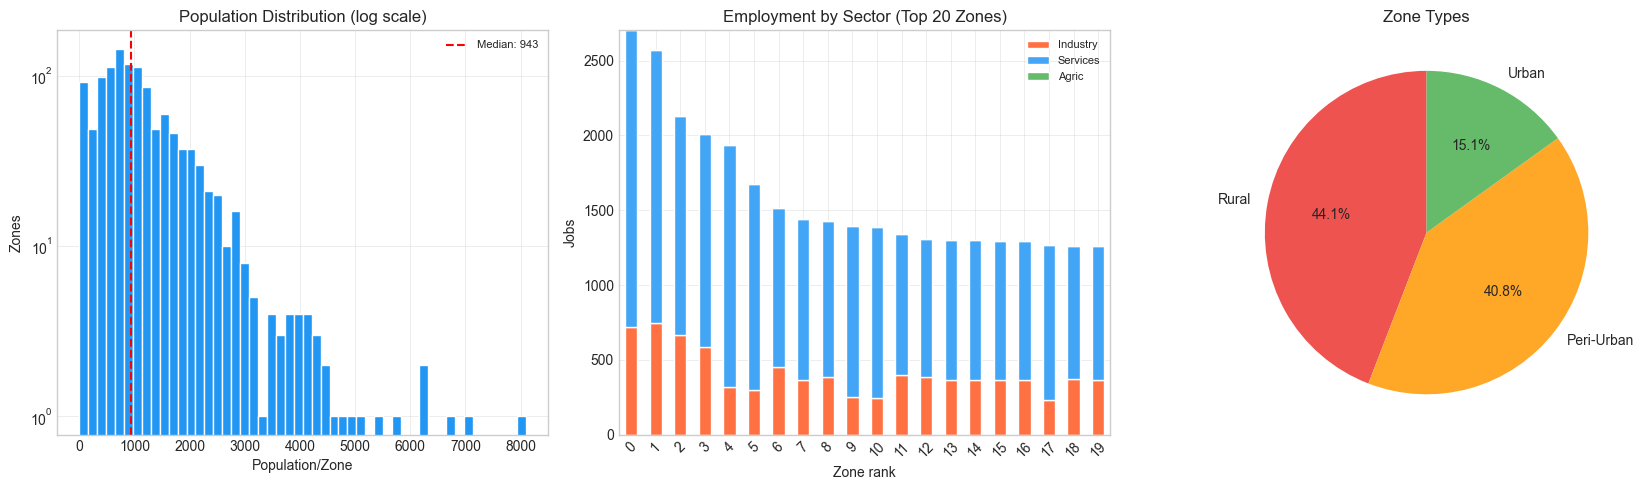

✓ Saved: 11_1_zones.png


In [10]:
# ── CELL 10: Visualise Zones ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].hist(zones["population"], bins=50, color="#2196F3", edgecolor="white", log=True)
axes[0].axvline(zones["population"].median(), color="red", ls="--",
                label=f'Median: {zones["population"].median():.0f}')
axes[0].set(title="Population Distribution (log scale)", xlabel="Population/Zone",
            ylabel="Zones"); axes[0].legend(fontsize=8)

top20 = zones.nlargest(20,"total_employment")[["emp_industry","emp_services","emp_agriculture"]]
top20.reset_index(drop=True).plot(kind="bar", stacked=True, ax=axes[1],
    color=["#FF7043","#42A5F5","#66BB6A"], edgecolor="white")
axes[1].set(title="Employment by Sector (Top 20 Zones)", xlabel="Zone rank",
            ylabel="Jobs"); axes[1].legend(["Industry","Services","Agric"], fontsize=8)
axes[1].tick_params(axis="x", rotation=45)

zt = zones["zone_type"].value_counts()
axes[2].pie(zt.values, labels=zt.index, autopct="%1.1f%%",
            colors=["#EF5350","#FFA726","#66BB6A"], startangle=90)
axes[2].set_title("Zone Types")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"11_1_zones.png"), dpi=150, bbox_inches="tight")
plt.show()
print("\u2713 Saved: 11_1_zones.png")


---
## Sub-step 11.2 — Buildings Table

Each occupied housing unit from **Census 2024 OHU** becomes one building record.  
Building type, floor area, and year are assigned stochastically by zone type using  
`numpy` vectorised operations (not a slow Python loop).


In [11]:
# ── CELL 11: Load OHU and Synthesise Buildings ───────────────────────────────
ohu_raw = pd.read_excel(PATHS["ohu"], sheet_name="Housing Units", header=3)
ohu_raw = clean_col(ohu_raw)
ohu_raw = ohu_raw.dropna(how="all")

# Filter to Kandy (district code 21 or name "Kandy")
dist_code_col = next((c for c in ohu_raw.columns
                      if "district" in c.lower() and "code" in c.lower()), None)
if dist_code_col:
    ohu_raw[dist_code_col] = safe_num(ohu_raw[dist_code_col])
    ohu_k = ohu_raw[ohu_raw[dist_code_col] == 21].copy()
else:
    dn_col = next((c for c in ohu_raw.columns if "district" in c.lower()), None)
    ohu_k = ohu_raw[ohu_raw[dn_col].astype(str).str.contains("Kandy", na=False)].copy()

# OHU count column
ohu_col = next((c for c in ohu_k.columns if "occupied" in c.lower()), "Occupied_Housing_Units")
gn_col  = next((c for c in ohu_k.columns if "gn_division_number" in c.lower()
                or "gn_number" in c.lower()), None)

ohu_k[ohu_col] = safe_num(ohu_k[ohu_col])
ohu_k[gn_col]  = safe_num(ohu_k[gn_col])

ohu_by_gn = (ohu_k.groupby(gn_col)[ohu_col].sum()
               .reset_index().rename(columns={gn_col:"GN_Number",
                                              ohu_col:"Occupied_Units"}))
ohu_by_gn["GN_Number"] = ohu_by_gn["GN_Number"].astype(int)
print(f"OHU  Kandy GN divisions: {len(ohu_by_gn):,}   Total units: {ohu_by_gn['Occupied_Units'].sum():,.0f}")

# Merge to TAZ
taz_ohu = (taz_m[["TAZ_ID","GN_Number","Zone_Type","Num_Househ","Avg_Land_Price"]]
           .assign(GN_Number=lambda d: d["GN_Number"].astype(int))
           .merge(ohu_by_gn, on="GN_Number", how="left"))
taz_ohu["n_bldg"] = taz_ohu["Occupied_Units"].fillna(taz_ohu["Num_Househ"]).fillna(0).clip(lower=0).astype(int)

# Vectorised synthesis
rng = np.random.default_rng(42)
zone_ids   = np.repeat(taz_ohu["TAZ_ID"].values,      taz_ohu["n_bldg"].values)
zone_types = np.repeat(taz_ohu["Zone_Type"].values,    taz_ohu["n_bldg"].values)
land_vals  = np.repeat(taz_ohu["Avg_Land_Price"].values, taz_ohu["n_bldg"].values)

type_probs = {"Urban":[.20,.40,.35,.05],"Peri-Urban":[.45,.35,.15,.05],"Rural":[.70,.25,.04,.01]}
btype = np.ones(len(zone_ids), dtype=int)
for zt, p in type_probs.items():
    m = zone_types == zt
    if m.sum(): btype[m] = rng.choice([1,2,3,4], size=m.sum(), p=p)

sqft_base = np.vectorize({1:900,2:750,3:620,4:1200}.get)(btype,900)
sqft = (sqft_base + rng.normal(0, sqft_base*.15, len(zone_ids))).clip(min=300).astype(int)
year = rng.choice([1980,1990,1995,2000,2005,2010,2015,2020],
                  p=[.05,.10,.10,.20,.15,.15,.15,.10], size=len(zone_ids))
res_units = np.where(btype==3, rng.choice([4,6,8,12], p=[.3,.3,.2,.2], size=len(zone_ids)),
             np.where(btype==2, 2, 1))
land_area = np.where(zone_types=="Urban",    rng.integers(100,400,len(zone_ids)),
             np.where(zone_types=="Peri-Urban", rng.integers(200,800,len(zone_ids)),
                                               rng.integers(400,2000,len(zone_ids))))

buildings = pd.DataFrame({
    "zone_id":zone_ids, "building_type_id":btype,
    "residential_units":res_units, "non_residential_sqft":np.where(btype==4,sqft,0),
    "sqft_per_unit":sqft, "year_built":year,
    "land_area_m2":land_area, "land_value_lkr":(land_vals*land_area/20.23).astype(int),
})
buildings.index = range(1, len(buildings)+1); buildings.index.name = "building_id"

if URBANSIM_AVAILABLE:
    orca.add_table("buildings", buildings)
    print("\u2713 Buildings registered with Orca")

table_summary("BUILDINGS", buildings)
save_csv(buildings, "buildings_final")


OHU  Kandy GN divisions: 1,187   Total units: 389,826
✓ Buildings registered with Orca

  TABLE: BUILDINGS
  Rows: 390,484   Cols: ['zone_id', 'building_type_id', 'residential_units', 'non_residential_sqft', 'sqft_per_unit', 'year_built']...
  zone_id                      min=         1.0  max=     1,187.0
  building_type_id             min=         1.0  max=         4.0
  residential_units            min=         1.0  max=        12.0
  non_residential_sqft         min=         0.0  max=     1,872.0
  sqft_per_unit                min=       300.0  max=     1,872.0
  year_built                   min=     1,980.0  max=     2,020.0
  Saved → E:\LUTI Research\kandy_luti\matsim\buildings_final.csv


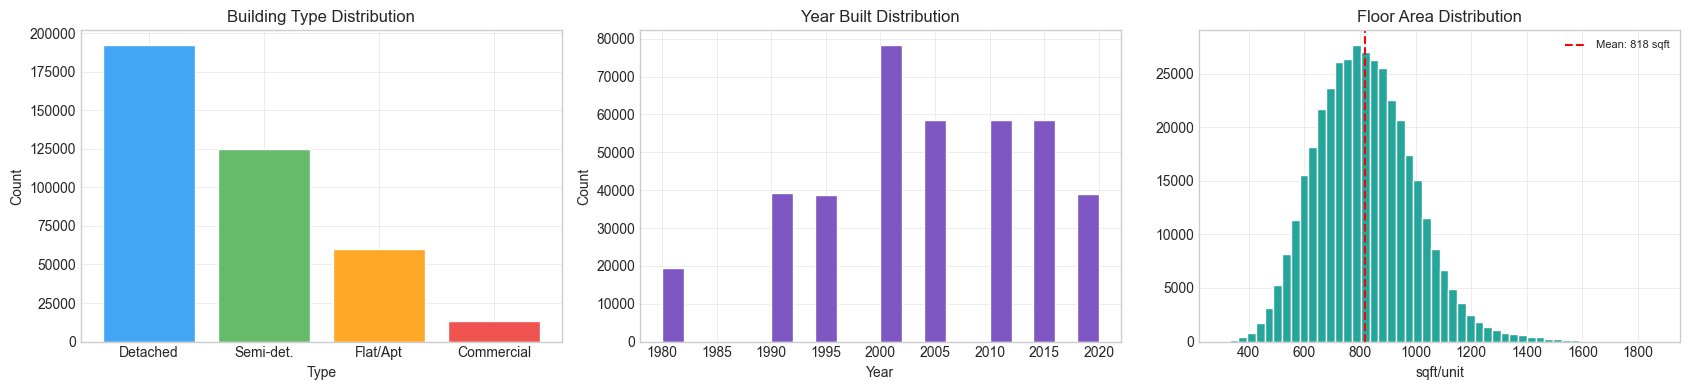

In [12]:
# ── CELL 12: Visualise Buildings ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
lbl = {1:"Detached",2:"Semi-det.",3:"Flat/Apt",4:"Commercial"}
tc = buildings["building_type_id"].map(lbl).value_counts()
axes[0].bar(tc.index, tc.values, color=["#42A5F5","#66BB6A","#FFA726","#EF5350"],
            edgecolor="white")
axes[0].set(title="Building Type Distribution", xlabel="Type", ylabel="Count")

axes[1].hist(buildings["year_built"], bins=20, color="#7E57C2", edgecolor="white")
axes[1].set(title="Year Built Distribution", xlabel="Year", ylabel="Count")

axes[2].hist(buildings["sqft_per_unit"], bins=50, color="#26A69A", edgecolor="white")
axes[2].axvline(buildings["sqft_per_unit"].mean(), color="red", ls="--",
                label=f'Mean: {buildings["sqft_per_unit"].mean():.0f} sqft')
axes[2].set(title="Floor Area Distribution", xlabel="sqft/unit"); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"11_2_buildings.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## Sub-step 11.3 — Households Table

**Income source:** `HH_Income_GN_SriLanka.xlsx` — HIES 2019 proxy estimates  
anchored to Kandy District actual (mean LKR 65,420/month, Gini 0.44).  
Sector adjustment factors: Urban × 1.527, Peri-Urban × 1.10, Rural × 0.91.


In [13]:
# ── CELL 13: Load Income Data ────────────────────────────────────────────────
# Same structure as employment file: header=3 already reads the correct row.
inc_raw = pd.read_excel(PATHS["income"], sheet_name="GN_Level_Dataset", header=3)
inc_raw = clean_col(inc_raw)
inc_raw = inc_raw.dropna(how="all")

print(f"Income columns (first 8): {list(inc_raw.columns[:8])}")

sector_col   = next((c for c in inc_raw.columns if "sector" in c.lower()), None)
mean_col     = next((c for c in inc_raw.columns if "mean" in c.lower()
                     and "income" in c.lower() and "district" not in c.lower()), None)
district_col = next((c for c in inc_raw.columns if "district" in c.lower()
                     and "name" not in c.lower() and "div" not in c.lower()), None)

print(f"Columns identified:  sector={sector_col}  mean_income={mean_col}")

# Kandy-specific or fallback to calibrated priors (Waddell 2002 + HIES 2019)
INCOME_PARAMS = {
    "Urban"     : {"mean": 99906,  "sigma": 0.50},   # 65420 * 1.527
    "Peri-Urban": {"mean": 71962,  "sigma": 0.55},   # 65420 * 1.10
    "Rural"     : {"mean": 59532,  "sigma": 0.60},   # 65420 * 0.91
}

if sector_col and mean_col:
    inc_kandy = inc_raw.copy()
    if district_col:
        inc_kandy = inc_raw[inc_raw[district_col].astype(str).str.contains(
                    "Kandy", na=False)].copy()
    inc_kandy[mean_col] = safe_num(inc_kandy[mean_col])
    by_sec = inc_kandy.groupby(sector_col)[mean_col].mean()
    for sec, val in by_sec.items():
        if val > 0:
            sec_str = str(sec).strip()
            if "urban" in sec_str.lower() and "peri" not in sec_str.lower():
                INCOME_PARAMS["Urban"]["mean"]      = int(val)
            elif "peri" in sec_str.lower():
                INCOME_PARAMS["Peri-Urban"]["mean"] = int(val)
            elif "rural" in sec_str.lower() or "estate" in sec_str.lower():
                INCOME_PARAMS["Rural"]["mean"]      = int(val)

print("\nIncome parameters used:")
for zt, p in INCOME_PARAMS.items():
    print(f"  {zt:12s}  mean = LKR {p['mean']:>8,}   sigma = {p['sigma']:.2f}")


Income columns (first 8): ['GN_ID', 'GN_Division_Name', 'DS_Division', 'District', 'Province', 'Sector', 'Est_Mean_Monthly_Income_Rs', 'Est_Median_Monthly_Income_Rs']
Columns identified:  sector=Sector  mean_income=Est_Mean_Monthly_Income_Rs

Income parameters used:
  Urban         mean = LKR  114,238   sigma = 0.50
  Peri-Urban    mean = LKR   71,962   sigma = 0.55
  Rural         mean = LKR   68,068   sigma = 0.60


In [14]:
# ── CELL 14: Build Households Table (Vectorised) ─────────────────────────────
rng2 = np.random.default_rng(123)
res_bldg = buildings[buildings["building_type_id"].isin([1,2,3])].reset_index()
bld_ids  = np.repeat(res_bldg["building_id"].values, res_bldg["residential_units"].values)
zon_ids  = np.repeat(res_bldg["zone_id"].values,     res_bldg["residential_units"].values)
zt_map   = zones["zone_type"].to_dict()
hh_zt    = np.array([zt_map.get(z,"Rural") for z in zon_ids])

# Persons
persons = np.ones(len(bld_ids), dtype=int)
for zt, p in [("Urban",[.08,.25,.35,.22,.10]),
              ("Peri-Urban",[.05,.20,.35,.28,.12]),
              ("Rural",[.04,.15,.30,.33,.18])]:
    m = hh_zt == zt
    if m.sum(): persons[m] = rng2.choice([1,2,3,4,5], p=p, size=m.sum())

# Income (lognormal anchored to HIES 2019)
income = np.zeros(len(bld_ids))
for zt, prm in INCOME_PARAMS.items():
    m = hh_zt == zt
    if m.sum():
        mu = np.log(prm["mean"]) - prm["sigma"]**2/2
        income[m] = rng2.lognormal(mu, prm["sigma"], m.sum())
income = np.clip(income, 12000, 2_000_000).astype(int)

workers = np.minimum(persons, rng2.choice([0,1,2], p=[.12,.52,.36], size=len(bld_ids)))
decile  = pd.qcut(income, q=10, labels=False) + 1

households = pd.DataFrame({
    "building_id":bld_ids, "zone_id":zon_ids,
    "persons":persons, "income":income,
    "workers":workers, "income_decile":decile.astype(int),
})
households.index = range(1, len(households)+1)
households.index.name = "household_id"

# ── Scale to census household count ──────────────────────────────────────────
# Buildings were synthesised from OHU rows (1 row = 1 occupied housing unit).
# Multi-unit buildings (type 3 apartments = 4-12 units, type 2 semis = 2 units)
# then generate multiple households each, inflating totals above census.
# Sub-sample (or upsample) to match zones["num_households"].sum() exactly.
_target_hh = int(zones["num_households"].sum())
_raw_n     = len(households)
if _raw_n > _target_hh:
    households = (households.sample(n=_target_hh, random_state=42)
                             .sort_index().copy())
elif _raw_n < _target_hh:
    _extra = households.sample(n=_target_hh - _raw_n, replace=True, random_state=42)
    households = pd.concat([households, _extra]).copy()
households.index = range(1, len(households)+1)
households.index.name = "household_id"
# Recompute income decile after resample
households["income_decile"] = (pd.qcut(households["income"], q=10,
                                       labels=False, duplicates="drop") + 1).astype(int)
print(f"  HH count scaled: {_raw_n:,} → {len(households):,}  (census target: {_target_hh:,})")

if URBANSIM_AVAILABLE:
    orca.add_table("households", households)
    print("\u2713 Households registered with Orca")

table_summary("HOUSEHOLDS", households)
print(f"  Mean income  : LKR {households['income'].mean():>10,.0f}/month")
print(f"  Median income: LKR {households['income'].median():>10,.0f}/month  (HIES 2019 Kandy: LKR 65,420)")
save_csv(households, "households_final")


  HH count scaled: 861,497 → 365,339  (census target: 365,339)
✓ Households registered with Orca

  TABLE: HOUSEHOLDS
  Rows: 365,339   Cols: ['building_id', 'zone_id', 'persons', 'income', 'workers', 'income_decile']...
  building_id                  min=         1.0  max=   390,484.0
  zone_id                      min=         1.0  max=     1,187.0
  persons                      min=         1.0  max=         5.0
  income                       min=    12,000.0  max=   855,614.0
  workers                      min=         0.0  max=         2.0
  income_decile                min=         1.0  max=        10.0
  Mean income  : LKR     87,017/month
  Median income: LKR     73,807/month  (HIES 2019 Kandy: LKR 65,420)
  Saved → E:\LUTI Research\kandy_luti\matsim\households_final.csv


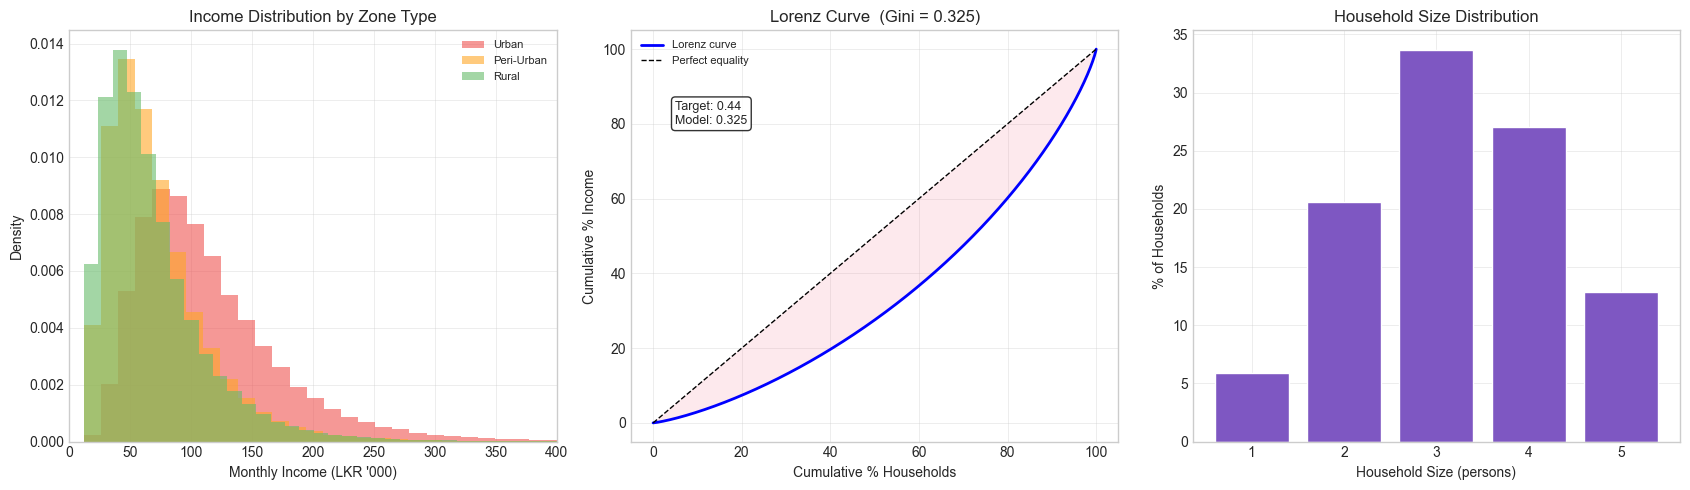

In [15]:
# ── CELL 15: Household Income Diagnostics ────────────────────────────────────
# NumPy 2.0 compat: np.trapz removed; np.trapezoid is the replacement
_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Income histograms by zone type
for zt, col in [("Urban","#EF5350"),("Peri-Urban","#FFA726"),("Rural","#66BB6A")]:
    m = np.array([zt_map.get(z,"Rural") for z in households["zone_id"].values]) == zt
    axes[0].hist(households.loc[m,"income"]/1000, bins=60, alpha=.6,
                 color=col, label=zt, density=True)
axes[0].set(xlim=(0,400), xlabel="Monthly Income (LKR '000)", ylabel="Density",
            title="Income Distribution by Zone Type"); axes[0].legend(fontsize=8)

# Lorenz curve
si = np.sort(households["income"].values)
ci = np.cumsum(si)/si.sum(); cp = np.arange(1,len(si)+1)/len(si)
gini = 1 - 2*_trapz(ci,cp)
axes[1].plot(cp*100, ci*100, "b-", lw=2, label="Lorenz curve")
axes[1].plot([0,100],[0,100],"k--",lw=1,label="Perfect equality")
axes[1].fill_between(cp*100, ci*100, cp*100, alpha=.15)
axes[1].set(xlabel="Cumulative % Households", ylabel="Cumulative % Income",
            title=f"Lorenz Curve  (Gini = {gini:.3f})")
axes[1].text(5,80,f"Target: 0.44\nModel: {gini:.3f}",fontsize=9,
             bbox=dict(boxstyle="round",fc="white",alpha=.8))
axes[1].legend(fontsize=8)

# Household size
hs = households["persons"].value_counts().sort_index()
axes[2].bar(hs.index, hs.values/hs.sum()*100, color="#7E57C2", edgecolor="white")
axes[2].set(xlabel="Household Size (persons)", ylabel="% of Households",
            title="Household Size Distribution")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"11_3_households.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## Sub-step 11.4 — Jobs Table

One record per job, with `sector_id` (1=Agriculture, 2=Industry, 3=Services)  
and `building_id = -1` (unplaced — assigned by ELCM in Step 17).

In [16]:
# ── CELL 16: Build Jobs Table (Vectorised) ──────────────────────────────────
job_zones = zones[["total_employment","emp_industry","emp_services","emp_agriculture"]]
job_zones = job_zones[job_zones["total_employment"] > 0]

z_idx = job_zones.index.values
all_z, all_s = [], []
for col, sid in [("emp_agriculture",1),("emp_industry",2),("emp_services",3)]:
    counts = job_zones[col].values.astype(int)
    all_z.append(np.repeat(z_idx, counts))
    all_s.append(np.full(counts.sum(), sid, dtype=int))

jobs = pd.DataFrame({
    "zone_id"    : np.concatenate(all_z),
    "sector_id"  : np.concatenate(all_s),
    "building_id": -1,
})
jobs.index = range(1, len(jobs)+1); jobs.index.name = "job_id"

if URBANSIM_AVAILABLE:
    orca.add_table("jobs", jobs)
    print("\u2713 Jobs registered with Orca")

table_summary("JOBS", jobs)
for sid, sname in [(1,"Agriculture"),(2,"Industry"),(3,"Services")]:
    n = (jobs["sector_id"]==sid).sum()
    print(f"  {sname:12s}: {n:>8,d}  ({n/len(jobs)*100:.1f}%)")
save_csv(jobs, "jobs_final")


✓ Jobs registered with Orca

  TABLE: JOBS
  Rows: 423,441   Cols: ['zone_id', 'sector_id', 'building_id']...
  zone_id                      min=         1.0  max=     1,187.0
  sector_id                    min=         2.0  max=         3.0
  building_id                  min=        -1.0  max=        -1.0
  Agriculture :        0  (0.0%)
  Industry    :   98,828  (23.3%)
  Services    :  324,613  (76.7%)
  Saved → E:\LUTI Research\kandy_luti\matsim\jobs_final.csv


---
## Sub-step 11.5 — Hedonic Price Model

**Specification:**  $\ln(P_i) = \beta_0 + \beta_1 \cdot d_{CBD} + \sum_j \beta_j \cdot \text{ZoneType}_{ij} + \varepsilon_i$

**Data:** 58 verified land price observations from `Kandy_Property_Values_Dataset.xlsx`  
(LankaPropertyWeb + ikman.lk, Nov 2024 – Mar 2025).

At each LUTI cycle the hedonic model is re-run with updated accessibility to re-price all zones.


In [17]:
# ── CELL 17: Hedonic Regression ─────────────────────────────────────────────
land_df["log_price"] = np.log(land_df["Land_Price_Per_Perch_LKR"])
zdums = pd.get_dummies(land_df["Zone_Type"], prefix="zone").astype(float)
ref   = [c for c in zdums.columns if "urban_core" in c.lower() or "Urban_Core" in c]
if ref: zdums = zdums.drop(columns=ref[0])

reg_data = pd.concat([land_df[["log_price","Distance_To_Kandy_CBD_km"]], zdums], axis=1).dropna()
X = sm.add_constant(reg_data.drop(columns=["log_price"]))
y = reg_data["log_price"]
hedonic = sm.OLS(y, X).fit()

print(hedonic.summary())
print(f"\nR\u00b2: {hedonic.rsquared:.4f}   Adj-R\u00b2: {hedonic.rsquared_adj:.4f}")
print("\nCoefficient effects on price:")
for nm, c, p in zip(hedonic.params.index, hedonic.params.values, hedonic.pvalues.values):
    sig = "***" if p<.01 else ("**" if p<.05 else ("*" if p<.1 else "   "))
    print(f"  {nm:35s}  {c:+.4f} {sig}  => {(np.exp(c)-1)*100:+.1f}% price change")


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     70.83
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           5.41e-22
Time:                        18:43:58   Log-Likelihood:                -32.228
No. Observations:                  58   AIC:                             76.46
Df Residuals:                      52   BIC:                             88.82
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

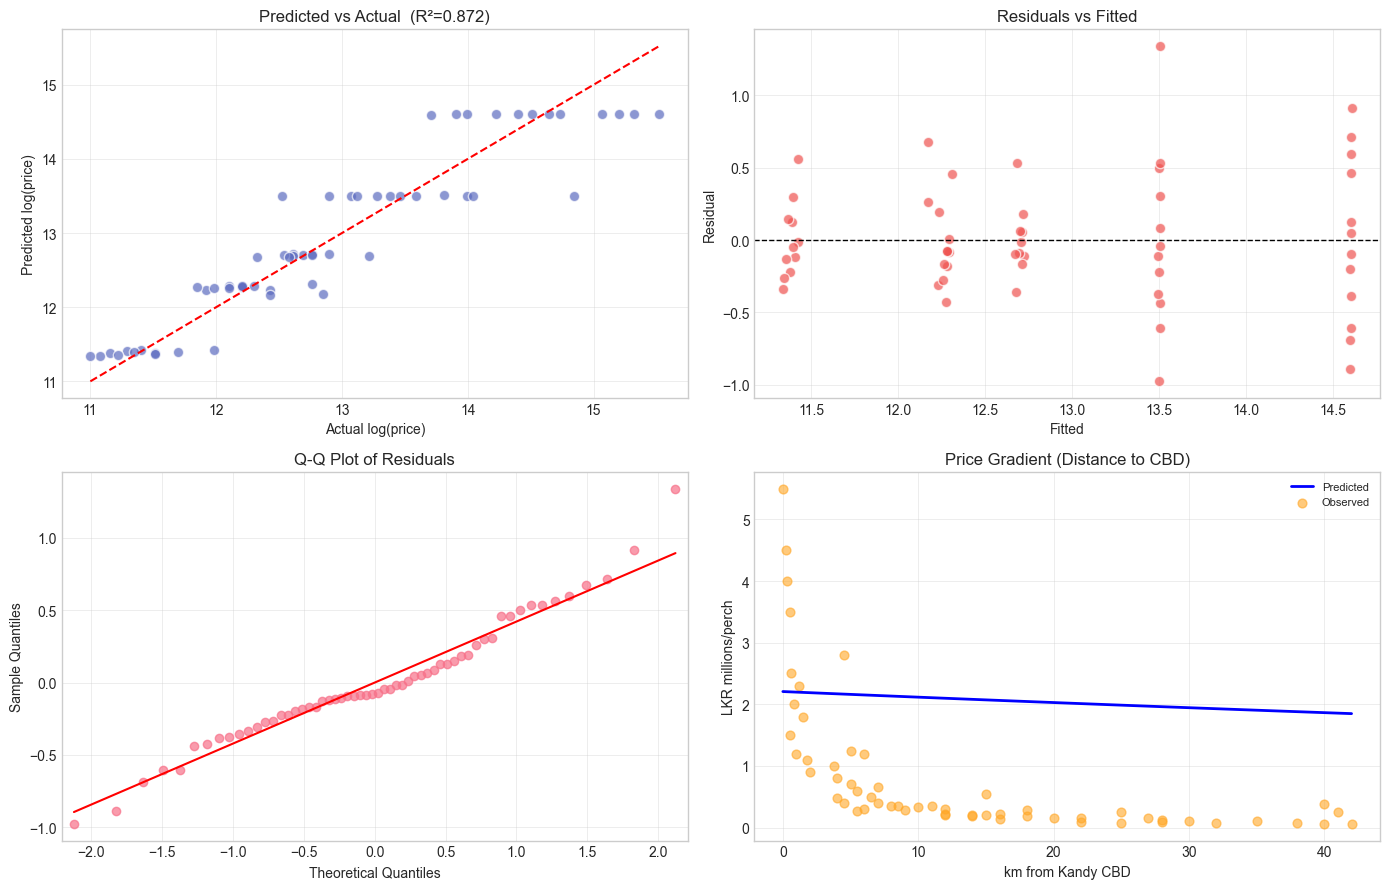

  Predicted land prices by zone type:
    Urban       : LKR      321,902 –    2,204,484/perch  (n=179)
    Peri-Urban  : LKR      208,325 –      227,208/perch  (n=484)
    Rural       : LKR       83,980 –       98,672/perch  (n=524)
Zones priced:  LKR 83,980 – 2,204,484/perch
✓ Hedonic coefficients saved


In [18]:
# ── CELL 18: Hedonic Diagnostics + Apply to All Zones ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

yp = hedonic.fittedvalues
axes[0,0].scatter(y, yp, alpha=.7, color="#5C6BC0", edgecolors="white", s=55)
mn,mx = min(y.min(),yp.min()), max(y.max(),yp.max())
axes[0,0].plot([mn,mx],[mn,mx],"r--",lw=1.5)
axes[0,0].set(title=f"Predicted vs Actual  (R\u00b2={hedonic.rsquared:.3f})",
              xlabel="Actual log(price)", ylabel="Predicted log(price)")

res = hedonic.resid
axes[0,1].scatter(yp, res, alpha=.7, color="#EF5350", edgecolors="white", s=55)
axes[0,1].axhline(0, color="k", ls="--", lw=1)
axes[0,1].set(title="Residuals vs Fitted", xlabel="Fitted", ylabel="Residual")

sm.qqplot(res, line="s", ax=axes[1,0], alpha=.7)
axes[1,0].set_title("Q-Q Plot of Residuals")

dv = np.linspace(0, land_df["Distance_To_Kandy_CBD_km"].max(), 100)
pred_df = pd.DataFrame({"const":1,"Distance_To_Kandy_CBD_km":dv})
for c in X.columns:
    if c not in pred_df.columns: pred_df[c] = 0.0
pred_df = pred_df[X.columns]
axes[1,1].plot(dv, np.exp(hedonic.predict(pred_df))/1e6, "b-", lw=2, label="Predicted")
axes[1,1].scatter(land_df["Distance_To_Kandy_CBD_km"],
                  land_df["Land_Price_Per_Perch_LKR"]/1e6,
                  alpha=.6, color="#FFA726", s=40, label="Observed")
axes[1,1].set(title="Price Gradient (Distance to CBD)",
              xlabel="km from Kandy CBD", ylabel="LKR millions/perch")
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"11_5_hedonic.png"), dpi=150, bbox_inches="tight")
plt.show()

# Apply to all zones
KANDY_CBD = (7.2906, 80.6337)

def hav(lat1,lon1,lat2,lon2):
    R=6371; dl=np.radians(lat2-lat1); dn=np.radians(lon2-lon1)
    a=np.sin(dl/2)**2+np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dn/2)**2
    return R*2*np.arcsin(np.sqrt(a))

# taz_m has 1194 rows; zones has 1187 (deduplicated on TAZ_ID).
# Steps:
#   1. Set index to TAZ_ID
#   2. Drop the 7 duplicate TAZ_IDs (keep first) — required before reindex()
#   3. reindex() aligns on zone_id; any remaining gaps filled with median
cents = taz_m.set_index("TAZ_ID").copy()
cents["clat"] = cents.geometry.centroid.y
cents["clon"]  = cents.geometry.centroid.x
cents["dist_cbd"] = hav(cents["clat"].values, cents["clon"].values, *KANDY_CBD)
cents = cents[~cents.index.duplicated(keep="first")]   # drop duplicate TAZ_IDs

zones["dist_to_cbd_km"] = (cents["dist_cbd"]
                            .reindex(zones.index)
                            .fillna(cents["dist_cbd"].median()))

# ── Build prediction matrix with correct zone-type dummies ───────────────────
# Hedonic model: reference category = Urban_Core (Urban zone, dist < 3 km)
# All other zone types get the appropriate dummy set to 1.
#
# Auto-detect the actual dummy column names from hedonic.params (handles both
# "zone_Peri-Urban" and "zone_Peri_Urban" spellings from pd.get_dummies).
_hcols = {c.lower().replace("-","_"): c for c in hedonic.params.index}
_c_inner = next((v for k,v in _hcols.items() if "inner"  in k), None)
_c_outer = next((v for k,v in _hcols.items() if "outer"  in k), None)
_c_peri  = next((v for k,v in _hcols.items() if "peri"   in k), None)
_c_rural = next((v for k,v in _hcols.items() if "rural"  in k), None)

_zt = zones["zone_type"].str.strip()
_d  = zones["dist_to_cbd_km"]

prd = pd.DataFrame({"const":1,"Distance_To_Kandy_CBD_km":_d}, index=zones.index)
for c in hedonic.params.index:
    if c not in prd.columns:
        prd[c] = 0.0

# Assign dummies: Urban_Core (dist<3 km) = reference (all dummies = 0)
if _c_inner: prd[_c_inner] = ((_zt=="Urban") & (_d>=3) & (_d<8)).astype(float)
if _c_outer: prd[_c_outer] = ((_zt=="Urban") & (_d>=8)).astype(float)
if _c_peri:  prd[_c_peri]  = (_zt=="Peri-Urban").astype(float)
if _c_rural: prd[_c_rural] = (_zt=="Rural").astype(float)

prd = prd[hedonic.params.index]
zones["predicted_land_price"] = np.exp(hedonic.predict(prd)).round(0).astype(int)

# Summary by zone type
print("  Predicted land prices by zone type:")
for zt_label in ["Urban","Peri-Urban","Rural"]:
    m = zones["zone_type"]==zt_label
    if m.sum():
        sub = zones.loc[m,"predicted_land_price"]
        print(f"    {zt_label:12s}: LKR {sub.min():>12,.0f} – {sub.max():>12,.0f}/perch  (n={m.sum()})")

if URBANSIM_AVAILABLE:
    orca.add_table("zones", zones)

pd.DataFrame({"coef":hedonic.params,"se":hedonic.bse,"p":hedonic.pvalues}).to_csv(
    os.path.join(OUTPUT_DIR,"hedonic_coefficients.csv"))
print(f"Zones priced:  LKR {zones['predicted_land_price'].min():,.0f} \u2013 {zones['predicted_land_price'].max():,.0f}/perch")
print("\u2713 Hedonic coefficients saved")


---
## Sub-step 11.6 — Household Location Choice Model (HLCM)

**Utility function (MNL / Random Utility Maximisation):**

$$V_{iz} = \beta_1\ln(P_z) + \beta_2\ln(\rho_z) + \beta_3\ln(E_z) + \beta_4 d_{z,CBD}$$

Coefficients are calibrated priors from South/Southeast Asian LUTI literature  
(Waddell 2002; Simmonds 2001). They will be refined against the 2005→2010  
back-cast in Step 14 (Historical Validation).


In [19]:
# ── CELL 19: Configure HLCM ─────────────────────────────────────────────────
HLCM_BETA = {
    "log_price"       : -0.620,   # households avoid expensive zones
    "log_pop_density" : +0.230,   # mild agglomeration preference
    "log_employment"  : +0.310,   # employment access improves attractiveness
    "dist_to_cbd_km"  : -0.180,   # prefer proximity to CBD
}

hz = zones.copy()
hz["log_price"]       = np.log1p(hz["predicted_land_price"])
hz["log_pop_density"] = np.log1p(hz["population"] / hz["area_sqkm"].replace(0,np.nan)).fillna(0)
hz["log_employment"]  = np.log1p(hz["total_employment"])
hz = hz.fillna(0)

util = (HLCM_BETA["log_price"]       * hz["log_price"]
      + HLCM_BETA["log_pop_density"] * hz["log_pop_density"]
      + HLCM_BETA["log_employment"]  * hz["log_employment"]
      + HLCM_BETA["dist_to_cbd_km"]  * hz["dist_to_cbd_km"])

exp_u = np.exp(util - util.max())
hz["choice_prob"] = exp_u / exp_u.sum()

print("HLCM coefficients (calibrated priors — Waddell 2002 / HIES 2019):")
for k,v in HLCM_BETA.items(): print(f"  {k:25s}: {v:+.3f}")
print(f"\nTop 5 preferred zones:")
print(hz.nlargest(5,"choice_prob")[["gn_name","ds_division","choice_prob"]].to_string())

pd.DataFrame.from_dict(HLCM_BETA,orient="index",columns=["beta"]).to_csv(
    os.path.join(OUTPUT_DIR,"hlcm_coefficients.csv"))
print("\n\u2713 HLCM coefficients saved")


HLCM coefficients (calibrated priors — Waddell 2002 / HIES 2019):
  log_price                : -0.620
  log_pop_density          : +0.230
  log_employment           : +0.310
  dist_to_cbd_km           : -0.180

Top 5 preferred zones:
                      gn_name   ds_division  choice_prob
zone_id                                                 
861           Madawala Madige  PATHADUMBARA     0.007828
845          Gunnepana Madige  PATHADUMBARA     0.006445
860                 Galewatta  PATHADUMBARA     0.006191
898      Udathalavinna Madige  PATHADUMBARA     0.006120
566             Kalugalawatta  PATHADUMBARA     0.006061

✓ HLCM coefficients saved


HLCM test  (500 movers): 329 unique zones selected
Top 5 destinations:
zone_id
888    6 household(s)
168    5 household(s)
574    5 household(s)
873    4 household(s)
699    4 household(s)


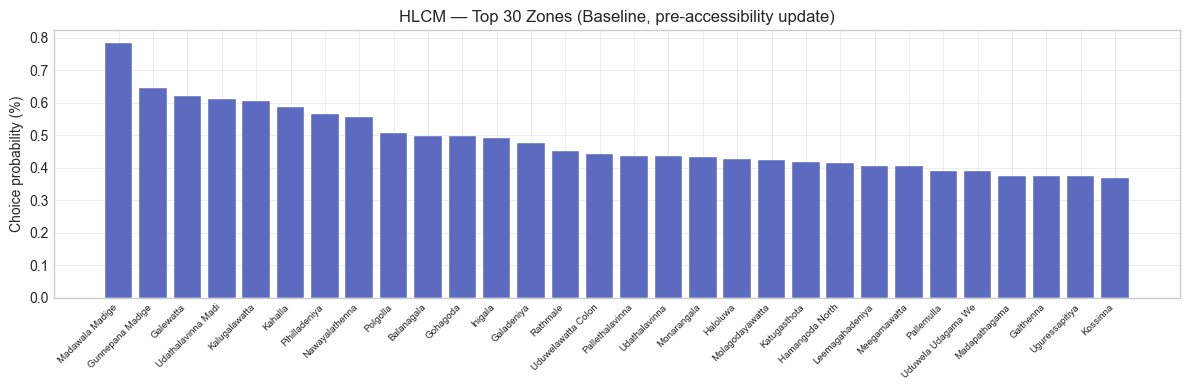

In [20]:
# ── CELL 20: HLCM Simulation Function + Test Run ────────────────────────────
def run_hlcm(n_movers, zones_df, beta=HLCM_BETA, seed=None):
    """
    Simulate HLCM: returns zone assignments for `n_movers` households.
    Called at each UrbanSim time-step to relocate mobile households.
    """
    rng_h = np.random.default_rng(seed)
    zd = zones_df.copy()
    zd["log_price"]       = np.log1p(zd.get("predicted_land_price", zd.get("avg_land_price",1)))
    zd["log_pop_density"] = np.log1p(zd.get("population",1)/zd.get("area_sqkm",1))
    zd["log_employment"]  = np.log1p(zd.get("total_employment",0))
    zd = zd.fillna(0)
    u  = (beta["log_price"]*zd["log_price"] + beta["log_pop_density"]*zd["log_pop_density"]
        + beta["log_employment"]*zd["log_employment"] + beta["dist_to_cbd_km"]*zd["dist_to_cbd_km"])
    eu = np.exp(u - u.max()); pr = (eu/eu.sum()).values
    return pd.Series(rng_h.choice(zd.index, size=n_movers, p=pr, replace=True), name="zone_id")

test = run_hlcm(500, hz, seed=42)
print(f"HLCM test  (500 movers): {test.nunique()} unique zones selected")
print("Top 5 destinations:"); print(test.value_counts().head().map(
    lambda v: f"{v} household(s)").to_string())

fig, ax = plt.subplots(figsize=(12, 4))
top30 = hz.nlargest(30,"choice_prob")
ax.bar(range(len(top30)), top30["choice_prob"]*100, color="#5C6BC0", edgecolor="white", lw=.3)
ax.set_xticks(range(len(top30)))
ax.set_xticklabels([n[:18] for n in top30["gn_name"]], rotation=45, ha="right", fontsize=7)
ax.set(ylabel="Choice probability (%)", title="HLCM — Top 30 Zones (Baseline, pre-accessibility update)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"11_6_hlcm.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## Sub-step 11.7 — Developer Model

Three-condition trigger: **(1)** zone occupancy > 80%  **(2)** FAR headroom available  **(3)** developer profit margin ≥ 15%.  
Zoning constraints from **UDA General Regulations 2018** (`Kandy_LandUse_Zoning_Dataset.xlsx`).


In [21]:
# ── CELL 21: Load Zoning + Build Parcels Table ───────────────────────────────
zoning_df  = pd.read_excel(PATHS["zoning"], sheet_name="Zoning_Categories")
parcels_df = pd.read_excel(PATHS["zoning"], sheet_name="LandUse_Parcel_Data")

zoning_lkp = {
    row["Zone Code"]: {
        "max_far"     : float(row["Max FAR"]),
        "max_height_m": float(row["Max Height (m)"]),
        "res_allowed" : str(row["Residential Allowed"]).lower() in
                        ["yes","above ground floor","limited"],
    }
    for _, row in zoning_df.iterrows()
}

ds_to_zone = (zones[["ds_division"]].reset_index()
              .groupby("ds_division")["zone_id"].first().to_dict())

parcels = pd.DataFrame({
    "parcel_id"           : parcels_df["Parcel_ID"],
    "ds_division"         : parcels_df["DS_Division"],
    "zone_code"           : parcels_df["Zone_Code"],
    "area_m2"             : parcels_df["Area_m2"].round(1),
    "far_current"         : parcels_df["FAR_Current"].round(3),
    "max_far_allowed"     : parcels_df["Max_FAR_Allowed"],
    "land_value_lkr_perch": parcels_df["Land_Value_LKR_perch"],
    "total_value_lkr"     : parcels_df["Total_Property_Value_LKR"],
    "lat"                 : parcels_df["Lat_approx"],
    "lon"                 : parcels_df["Lon_approx"],
}).assign(
    zone_id      = lambda d: d["ds_division"].map(ds_to_zone).fillna(-1).astype(int),
    far_headroom = lambda d: (d["max_far_allowed"] - d["far_current"]).clip(lower=0).round(3),
).set_index("parcel_id")

if URBANSIM_AVAILABLE:
    orca.add_table("parcels", parcels)
    print("\u2713 Parcels registered with Orca")

table_summary("PARCELS", parcels)
save_csv(parcels, "parcels_final")
print("\nZoning constraints:")
print(zoning_df[["Zone Code","Zone Name","Max FAR","Max Height (m)","Residential Allowed"]].to_string(index=False))


✓ Parcels registered with Orca

  TABLE: PARCELS
  Rows: 159   Cols: ['ds_division', 'zone_code', 'area_m2', 'far_current', 'max_far_allowed', 'land_value_lkr_perch']...
  area_m2                      min=       101.0  max=     7,385.0
  far_current                  min=         0.0  max=         3.0
  max_far_allowed              min=         0.1  max=         3.5
  land_value_lkr_perch         min=         0.0  max= 4,055,144.0
  total_value_lkr              min=         0.0  max=98,333,000.0
  lat                          min=         7.1  max=         7.5
  Saved → E:\LUTI Research\kandy_luti\matsim\parcels_final.csv

Zoning constraints:
Zone Code                  Zone Name  Max FAR  Max Height (m) Residential Allowed
       R1    Low-Density Residential      0.6             7.5                 Yes
       R2 Medium-Density Residential      1.2            10.5                 Yes
       R3   High-Density Residential      2.0            15.0                 Yes
       C1   Neighbourh

In [22]:
# ── CELL 22: Developer Model Function + Baseline Run ────────────────────────
def developer_model_step(zones_df, buildings_df, parcels_df, zoning_lkp,
                          occupancy_threshold=0.80, profit_min=0.15,
                          construction_lkr_m2={"residential":170000,"commercial":220000},
                          rng_seed=None):
    """
    One 5-year development step.
    Returns DataFrame of new building records.
    """
    rng_d = np.random.default_rng(rng_seed)
    new_bldgs = []
    
    # Supply by zone
    rb = buildings_df[buildings_df["building_type_id"].isin([1,2,3])]
    supply = rb.groupby("zone_id")["residential_units"].sum()
    
    for zone_id, demand in zones_df["num_households"].items():
        sup = supply.get(zone_id, 0)
        if sup == 0 or demand/sup < occupancy_threshold:
            continue
        
        zone_parcels = parcels_df[(parcels_df["zone_id"]==zone_id)
                                   & (parcels_df["far_headroom"]>0.1)]
        if zone_parcels.empty:
            continue
        
        bp = zone_parcels.nlargest(1,"far_headroom").iloc[0]
        zc = zoning_lkp.get(bp["zone_code"], {"max_far":1.0,"res_allowed":True})
        
        new_gfa   = bp["area_m2"] * min(bp["far_headroom"], zc["max_far"]*0.5)
        land_val  = bp["land_value_lkr_perch"] * bp["area_m2"] / 20.23
        c_type    = "residential" if zc.get("res_allowed",True) else "commercial"
        build_cost = new_gfa * construction_lkr_m2[c_type]
        revenue    = land_val*.8 + new_gfa*construction_lkr_m2["residential"]*1.4
        if (revenue - build_cost - land_val)/max(revenue,1) < profit_min:
            continue
        
        n_units = max(1, int(new_gfa/75))
        new_bldgs.append({
            "zone_id":zone_id, "building_type_id":1 if zc.get("res_allowed",True) else 4,
            "residential_units":n_units, "non_residential_sqft":0,
            "sqft_per_unit":int(new_gfa/n_units*10.764),
            "year_built":2025, "land_area_m2":int(bp["area_m2"]),
            "land_value_lkr":int(land_val),
        })
    return pd.DataFrame(new_bldgs)

new_b = developer_model_step(zones, buildings, parcels, zoning_lkp, rng_seed=99)
print(f"Developer Model — baseline step result:")
print(f"  Development events : {len(new_b)}")
if len(new_b) > 0:
    print(f"  New residential units: {new_b['residential_units'].sum():,}")
    print(f"  Zones developed      : {new_b['zone_id'].nunique()}")
    print(new_b.head(5).to_string(index=False))
else:
    print("  No development triggered (occupancy < 80% baseline — normal).")
    print("  Developer model activates in simulation years 2029+.")


Developer Model — baseline step result:
  Development events : 0
  No development triggered (occupancy < 80% baseline — normal).
  Developer model activates in simulation years 2029+.


---
## Model Integration — Orca Simulation Loop

The four `@orca.step` functions below define the complete **per-cycle LUTI loop**:

```
update_accessibility  →  run_hedonic_model  →  run_hlcm  →  run_developer_model
       ↑                                                              │
AequilibraE (Step 12) ←─────────── updated trip table ←─────────────┘
```


In [23]:
# ── CELL 23: Register Orca Steps ────────────────────────────────────────────
if URBANSIM_AVAILABLE:
    @orca.step("update_accessibility")
    def update_accessibility():
        """Load accessibility index from AequilibraE output (Step 12)."""
        zdf = orca.get_table("zones").to_frame()
        acc_path = os.path.join(OUTPUT_DIR,"..","step12","accessibility.csv")
        if os.path.exists(acc_path):
            acc = pd.read_csv(acc_path, index_col="zone_id")
            zdf["accessibility"] = acc["accessibility"]
            orca.add_table("zones", zdf)
            print(f"  \u2713 Accessibility updated from Step 12 output")
        else:
            print(f"  \u2139 Step 12 output not yet available — using baseline (1.0)")

    @orca.step("run_hedonic_model")
    def run_hedonic_model_step():
        """Re-price zones using updated accessibility."""
        zdf = orca.get_table("zones").to_frame()
        prd = pd.DataFrame({"const":1,"Distance_To_Kandy_CBD_km":zdf.get("dist_to_cbd_km",5)},
                           index=zdf.index)
        for c in hedonic.params.index:
            if c not in prd.columns: prd[c] = 0.0
        prd = prd[hedonic.params.index]
        zdf["predicted_land_price"] = np.exp(hedonic.predict(prd)).astype(int)
        orca.add_table("zones", zdf)
        print(f"  \u2713 Hedonic re-priced: LKR {zdf['predicted_land_price'].min():,.0f} \u2013 {zdf['predicted_land_price'].max():,.0f}")

    @orca.step("run_hlcm")
    def run_hlcm_step():
        """Relocate 5% of households each cycle."""
        zdf = orca.get_table("zones").to_frame()
        hdf = orca.get_table("households").to_frame()
        n_movers = max(1, int(len(hdf)*0.05))
        assignments = run_hlcm(n_movers, zdf, seed=None)
        mids = np.random.choice(hdf.index, n_movers, replace=False)
        hdf.loc[mids,"zone_id"] = assignments.values
        orca.add_table("households", hdf)
        pop_new = hdf.groupby("zone_id")["persons"].sum()
        zdf["population"] = pop_new.reindex(zdf.index).fillna(0).astype(int)
        orca.add_table("zones", zdf)
        print(f"  \u2713 HLCM ran — {n_movers:,} households relocated")

    @orca.step("run_developer_model")
    def run_developer_model_step():
        """Trigger new construction where occupancy > 80%."""
        zdf = orca.get_table("zones").to_frame()
        bdf = orca.get_table("buildings").to_frame()
        pdf = orca.get_table("parcels").to_frame()
        nb  = developer_model_step(zdf, bdf, pdf, zoning_lkp)
        if len(nb) > 0:
            nb.index = range(bdf.index.max()+1, bdf.index.max()+1+len(nb))
            nb.index.name = "building_id"
            orca.add_table("buildings", pd.concat([bdf, nb]))
            print(f"  \u2713 Developer: {nb['residential_units'].sum():,} new units")
        else:
            print(f"  \u2713 Developer: no construction triggered this step")

    print("\u2713 Orca steps registered:")
    print("  1. update_accessibility  2. run_hedonic_model  3. run_hlcm  4. run_developer_model")
    print("\nTo run one full LUTI cycle:")
    print("  orca.run(['update_accessibility','run_hedonic_model',")
    print("           'run_hlcm','run_developer_model'], iter_vars=[2025])")
else:
    print("UrbanSim/Orca not available.")
    print("All tables stored as DataFrames: zones, buildings, households, jobs, parcels")
    print("Call run_hlcm() and developer_model_step() directly for simulation.")


✓ Orca steps registered:
  1. update_accessibility  2. run_hedonic_model  3. run_hlcm  4. run_developer_model

To run one full LUTI cycle:
  orca.run(['update_accessibility','run_hedonic_model',
           'run_hlcm','run_developer_model'], iter_vars=[2025])


In [24]:
# ── CELL 24: Save All Tables ────────────────────────────────────────────────
print("Saving all UrbanSim tables...")
for nm, df in [("zones_final",zones), ("buildings_final",buildings),
               ("households_final",households), ("jobs_final",jobs),
               ("parcels_final",parcels)]:
    save_csv(df, nm)

print(f"\n{'='*58}")
print("  STEP 11 COMPLETE — all tables saved to outputs/step11/")
print(f"{'='*58}")


Saving all UrbanSim tables...
  Saved → E:\LUTI Research\kandy_luti\matsim\zones_final.csv
  Saved → E:\LUTI Research\kandy_luti\matsim\buildings_final.csv
  Saved → E:\LUTI Research\kandy_luti\matsim\households_final.csv
  Saved → E:\LUTI Research\kandy_luti\matsim\jobs_final.csv
  Saved → E:\LUTI Research\kandy_luti\matsim\parcels_final.csv

  STEP 11 COMPLETE — all tables saved to outputs/step11/


---
## Verification — 9 Automated Checks

Run before proceeding to Step 12.

In [25]:
# ── CELL 25: Verification ───────────────────────────────────────────────────
import numpy as np  # explicit import — makes cell self-contained under any kernel state
# NumPy 2.0 compat: np.trapz removed; np.trapezoid is the replacement
_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
checks = []

pop_zone = zones["population"].sum()
pop_hh   = households["persons"].sum()
pop_r    = pop_hh / max(pop_zone, 1)
emp_zone = zones["total_employment"].sum()
emp_jobs = len(jobs)
emp_r    = emp_jobs / max(emp_zone, 1)
hh_b_r   = len(households) / max(len(buildings[buildings["building_type_id"]<4]),1)
si2 = np.sort(households["income"].values)
ci2 = np.cumsum(si2)/si2.sum(); cp2 = np.arange(1,len(si2)+1)/len(si2)
gini2 = 1 - 2*_trapz(ci2,cp2)
null_z = buildings["zone_id"].isna().sum()
orphan = (~buildings["zone_id"].isin(zones.index)).sum()

checks = [
    ("Zone count \u2208 [900, 1300]",       900 <= len(zones) <= 1300),
    ("HH persons / zone pop \u2208 [0.8,1.2]", 0.8 <= pop_r <= 1.2),
    ("Jobs / zone employment \u2208 [0.9,1.1]", 0.9 <= emp_r <= 1.1),
    ("Avg HH per residential building \u2208 [0.5,3]", 0.5 <= hh_b_r <= 3.0),
    ("Hedonic R\u00b2 \u2265 0.50",         hedonic.rsquared >= 0.50),
    ("Mean income \u2208 [40k, 200k] LKR",  40000 <= households["income"].mean() <= 200000),
    ("Gini \u2208 [0.30, 0.55]",            0.30 <= gini2 <= 0.55),
    ("No null zone_id in buildings",         null_z == 0),
    ("All building zone_ids in zones",       orphan == 0),
]

print(f"{'='*60}\n  STEP 11 VERIFICATION REPORT\n{'='*60}")
print(f"  Zones: {len(zones):,}   Buildings: {len(buildings):,}   "
      f"Households: {len(households):,}   Jobs: {len(jobs):,}")
print(f"  Pop (zones): {pop_zone:,}   Pop (HH persons): {pop_hh:,}   Ratio: {pop_r:.3f}")
print(f"  Emp (zones): {emp_zone:,}   Jobs table: {emp_jobs:,}       Ratio: {emp_r:.3f}")
print(f"  Gini: {gini2:.3f}  (target 0.44)   Hedonic R\u00b2: {hedonic.rsquared:.3f}")
print()
n_pass = sum(ok for _,ok in checks)
for lbl, ok in checks:
    icon = "✓ PASS" if ok else "✗ FAIL"
    print(f"  {icon}  {lbl}")
print(f"\n  Result: {n_pass}/{len(checks)} checks passed")
if n_pass == len(checks):
    print("\n  \u2713 ALL CHECKS PASSED")
    print("  Proceed to Step 12: Build Transport Model in AequilibraE")
else:
    print("\n  \u26a0 Review failed checks before proceeding")
print("="*60)


  STEP 11 VERIFICATION REPORT
  Zones: 1,187   Buildings: 390,484   Households: 365,339   Jobs: 423,441
  Pop (zones): 1,371,698   Pop (HH persons): 1,170,485   Ratio: 0.853
  Emp (zones): 423,441   Jobs table: 423,441       Ratio: 1.000
  Gini: 0.325  (target 0.44)   Hedonic R²: 0.872

  ✓ PASS  Zone count ∈ [900, 1300]
  ✓ PASS  HH persons / zone pop ∈ [0.8,1.2]
  ✓ PASS  Jobs / zone employment ∈ [0.9,1.1]
  ✓ PASS  Avg HH per residential building ∈ [0.5,3]
  ✓ PASS  Hedonic R² ≥ 0.50
  ✓ PASS  Mean income ∈ [40k, 200k] LKR
  ✓ PASS  Gini ∈ [0.30, 0.55]
  ✓ PASS  No null zone_id in buildings
  ✓ PASS  All building zone_ids in zones

  Result: 9/9 checks passed

  ✓ ALL CHECKS PASSED
  Proceed to Step 12: Build Transport Model in AequilibraE


---
## Summary and Next Steps

### Outputs produced (`outputs/step11/`)

| File | Description |
|---|---|
| `zones_final.csv` | 1,187 TAZ zones with pop / emp / price |
| `buildings_final.csv` | Synthesised building inventory |
| `households_final.csv` | Households with HIES 2019 income proxies |
| `jobs_final.csv` | Jobs by sector |
| `parcels_final.csv` | Zoning-constrained parcel data |
| `hedonic_coefficients.csv` | OLS regression coefficients |
| `hlcm_coefficients.csv` | HLCM utility coefficients |
| `11_1_zones.png` … `11_6_hlcm.png` | Diagnostic figures |

### LUTI iteration schedule

| Cycle | Years | Action |
|---|---|---|
| 0 | 2024 | Baseline initialisation (this step) |
| 1 | 2025–2029 | Run transport → land use → update |
| 2 | 2030–2034 | As above |
| 3 | 2035–2039 | As above |
| 4 | 2040–2044 | Final scenario output |

### Calibration flags for Step 14 (Historical Validation)
- **HLCM β₁ (accessibility)** — reduce from −0.62 if model over-concentrates growth near roads
- **Developer occupancy threshold** — lower from 80% if model under-builds
- **Hedonic distance coefficient** — check CBD distance calculation if price gradient is too flat

### References
- Waddell, P. (2002). UrbanSim. *JAPA*, 68(3), 297–314.
- Rosen, S. (1974). Hedonic prices. *JPE*, 82(1), 34–55.
- DCS Sri Lanka. (2024). *Census of Population and Housing 2024*.
